In [ ]:
import pandas as pd
import numpy as np

df=pd.read_csv('total_data_monthly.csv')
df

,지역명,연도,인구밀도,인구밀도_평균,인구밀도_표준편차,인구밀도_,경사도_평균,경사도_최대,이재민 인,건물피해액,월,월강수량
0,강원특별자치도 강릉시,2012,209.32,-3726.751925,-0.599519,0.006620,17.641871,62.290401,23.0,7800.0,6.0,84.0
1,강원특별자치도 강릉시,2012,209.32,-3726.751925,-0.599519,0.006620,17.641871,62.290401,23.0,7800.0,7.0,1049.8
2,강원특별자치도 강릉시,2012,209.32,-3726.751925,-0.599519,0.006620,17.641871,62.290401,23.0,7800.0,8.0,1001.8
3,강원특별자치도 강릉시,2012,209.32,-3726.751925,-0.599519,0.006620,17.641871,62.290401,23.0,7800.0,9.0,877.5
4,강원특별자치도 강릉시,2013,208.39,-3727.681925,-0.599669,0.006588,17.641871,62.290401,0.0,0.0,6.0,114.6
...,...,...,...,...,...,...,...,...,...,...,...,...
6250,충청북도 충주시,2019,214.28,-3721.791925,-0.598721,0.006793,13.583274,57.877998,3.0,21000.0,9.0,413.0
6251,충청북도 충주시,2020,213.69,-3722.381925,-0.598816,0.006772,13.583274,57.877998,257.0,1119000.0,6.0,320.5
6252,충청북도 충주시,2020,213.69,-3722.381925,-0.598816,0.006772,13.583274,57.877998,257.0,1119000.0,7.0,1172.0
6253,충청북도 충주시,2020,213.69,-3722.381925,-0.598816,0.006772,13.583274,57.877998,257.0,1119000.0,8.0,1683.0


In [5]:
df['이재민 인'].describe()

count    6255.000000
mean       32.662510
std       159.362641
min         0.000000
25%         0.000000
50%         0.000000
75%         3.000000
max      3343.000000
Name: 이재민 인, dtype: float64

In [44]:
y = df['이재민 인'].values

# 1) log 변환 (0 문제 해결 + 꼬리 완화)
y_log = np.log1p(y)

# 2) 중심/스케일 잡기 (표준화: 평균0, 표준편차1)
mu = y_log.mean()
sd = y_log.std() + 1e-9
# x 변수 스케일 수정
x = (y_log - mu) / sd

# 3) sigmoid → 0~1
sig = 1 / (1 + np.exp(-x))

# 4) 0~M으로 스케일
M = 3343
y_scaled = M * sig
y_scaled

array([2625.14186204, 2625.14186204, 2625.14186204, ..., 3128.67803652,
       3128.67803652, 3128.67803652], shape=(6255,))

In [49]:
import numpy as np

y = df['이재민 인'].values
y_log = np.log1p(y)

# 기준점 c를 'log1p(0)=0'보다 크게 잡으면,
# y=0이 sigmoid의 왼쪽(작은 값)으로 가서 0에 가까워짐
c = np.percentile(y_log, 75)   # 75% 지점을 기준점으로
s = y_log.std() + 1e-9         # 기울기(스케일)

x = (y_log - c) / s
sig = 1 / (1 + np.exp(-x))

M = 3343
y_scaled = M * sig
y_scaled


array([2472.79016503, 2472.79016503, 2472.79016503, ..., 3072.16704737,
       3072.16704737, 3072.16704737], shape=(6255,))

In [67]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# =========================
# 0) 데이터
# =========================
M = 3343
features = ['인구밀도_log','경사도_평균','월강수량_log','강수대비_건물피해액']

X = df1[features].copy().replace([np.inf, -np.inf], np.nan)
y = df1['이재민_scaled'].copy()

# =========================
# 1) RMSE scorer (버전 호환)
# =========================
def rmse(y_true, y_pred):
    # y_scaled 범위 유지(중요)
    y_pred = np.clip(y_pred, 0, M)
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)  # cross_validate는 큰 값이 좋다고 가정하므로 음수로

# =========================
# 2) 모델 후보
# =========================
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=20000),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000),

    "RandomForest": RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=500, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),

    "KNN": KNeighborsRegressor(n_neighbors=15),
    "SVR(RBF)": SVR(C=10.0, epsilon=0.1)
}

need_scaler = {"LinearRegression","Ridge","Lasso","ElasticNet","KNN","SVR(RBF)"}

# =========================
# 3) CV 설정
# =========================
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# =========================
# 4) 모델별 CV 평가
# =========================
rows = []
for name, est in models.items():
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if name in need_scaler:
        steps.append(("scaler", StandardScaler()))
    steps.append(("reg", est))
    pipe = Pipeline(steps)

    scores = cross_validate(
        pipe, X, y,
        cv=cv,
        scoring={"rmse": rmse_scorer, "r2": "r2"},
        n_jobs=-1,
        return_train_score=False
    )

    rmse_vals = -scores["test_rmse"]  # 음수로 들어가 있으니 다시 양수로
    r2_vals = scores["test_r2"]

    rows.append({
        "model": name,
        "RMSE_mean": rmse_vals.mean(),
        "RMSE_std": rmse_vals.std(),
        "R2_mean": r2_vals.mean(),
        "R2_std": r2_vals.std()
    })

res = pd.DataFrame(rows).sort_values("RMSE_mean")
res



,model,RMSE_mean,RMSE_std,R2_mean,R2_std
5,ExtraTrees,468.225209,16.604876,0.726032,0.018411
4,RandomForest,468.244458,14.037397,0.726050,0.016432
6,GradientBoosting,508.527850,9.477050,0.676980,0.010976
7,KNN,547.777789,14.945468,0.625503,0.012722
0,LinearRegression,597.879717,11.712164,0.546706,0.006515
2,Lasso,597.879828,11.712178,0.546706,0.006515
1,Ridge,597.887902,11.713390,0.546706,0.006515
3,ElasticNet,597.900281,11.715239,0.546707,0.006514
8,SVR(RBF),632.530658,18.715409,0.500782,0.014008


In [68]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, f1_score, precision_score, recall_score, accuracy_score
)

# ====== 입력 ======
M = 3343
features = ['인구밀도_log','경사도_평균','월강수량_log','강수대비_건물피해액']
X_all = df1[features].copy().replace([np.inf, -np.inf], np.nan)

# 고위험 기준이 될 연속값 (원하는 걸로 택1)
score = df1['이재민_scaled'].astype(float).copy()   # 네가 만든 시그모이드 스코어를 기준으로 고위험 정의

# ====== 모델 후보 ======
models = {
    "LogReg(balanced)": ("scaled", LogisticRegression(max_iter=5000, class_weight="balanced")),
    "SVC(RBF, balanced)": ("scaled", SVC(C=3.0, gamma="scale", class_weight="balanced", probability=True)),
    "RandomForest": ("noscale", RandomForestClassifier(n_estimators=600, random_state=42, n_jobs=-1,
                                                     class_weight="balanced_subsample")),
    "ExtraTrees": ("noscale", ExtraTreesClassifier(n_estimators=600, random_state=42, n_jobs=-1,
                                                  class_weight="balanced")),
    "GradBoost": ("noscale", GradientBoostingClassifier(random_state=42)),
}

# ====== CV 설정 ======
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ====== 고위험 라벨 설정 ======
q = 0.80                 # 상위 20%를 고위험으로
target_recall = 0.80     # 고위험을 놓치지 않게(재현율 목표)

# NOTE: 라벨 임계값(threshold)은 "각 fold의 train 데이터에서만" 계산(누수 방지)
rows = []

for name, (scale_flag, clf) in models.items():
    pr_aucs, roc_aucs = [], []
    f1s, precs, recs, accs = [], [], [], []
    chosen_thresholds = []

    for tr_idx, te_idx in cv.split(X_all, (score > 0).astype(int)):  
        # split 기준은 아무거나 가능하지만, 최소한 stratify 성격을 위해 >0 여부 사용
        X_tr, X_te = X_all.iloc[tr_idx], X_all.iloc[te_idx]
        s_tr, s_te = score.iloc[tr_idx], score.iloc[te_idx]

        # ---- (핵심) 라벨 생성: "피해(>0)인 것들 중 상위 q"를 고위험(1) ----
        pos_tr = (s_tr > 0)
        if pos_tr.sum() == 0:
            continue
        thr = np.quantile(s_tr[pos_tr], q)

        y_tr = ((s_tr >= thr) & (s_tr > 0)).astype(int)
        y_te = ((s_te >= thr) & (s_te > 0)).astype(int)

        # ---- 파이프라인 ----
        steps = [("imputer", SimpleImputer(strategy="median"))]
        if scale_flag == "scaled":
            steps.append(("scaler", StandardScaler()))
        steps.append(("clf", clf))
        pipe = Pipeline(steps)

        pipe.fit(X_tr, y_tr)

        # 확률 예측(가능한 경우)
        if hasattr(pipe, "predict_proba"):
            proba = pipe.predict_proba(X_te)[:, 1]
        else:
            # decision_function을 0~1로 변환(간이)
            z = pipe.decision_function(X_te)
            proba = 1 / (1 + np.exp(-z))

        # ---- 임계값 튜닝: target_recall 이상이 되도록 threshold 선택 ----
        p, r, t = precision_recall_curve(y_te, proba)
        # precision_recall_curve에서 threshold t는 len = len(p)-1
        # recall 조건 만족하는 후보 중 precision 최대(또는 f1 최대)로 선택
        best_thr = 0.5
        best_prec = -1

        for i in range(len(t)):
            if r[i] >= target_recall:  # recall 조건 만족
                if p[i] > best_prec:
                    best_prec = p[i]
                    best_thr = t[i]

        chosen_thresholds.append(best_thr)

        y_pred = (proba >= best_thr).astype(int)

        # ---- 지표 ----
        pr_aucs.append(average_precision_score(y_te, proba))
        # roc_auc는 한 클래스만 있으면 에러날 수 있으니 try
        try:
            roc_aucs.append(roc_auc_score(y_te, proba))
        except Exception:
            roc_aucs.append(np.nan)

        f1s.append(f1_score(y_te, y_pred, zero_division=0))
        precs.append(precision_score(y_te, y_pred, zero_division=0))
        recs.append(recall_score(y_te, y_pred, zero_division=0))
        accs.append(accuracy_score(y_te, y_pred))

    rows.append({
        "model": name,
        "PR_AUC_mean": np.nanmean(pr_aucs),
        "ROC_AUC_mean": np.nanmean(roc_aucs),
        "F1_mean": np.mean(f1s) if len(f1s) else np.nan,
        "Precision_mean": np.mean(precs) if len(precs) else np.nan,
        "Recall_mean": np.mean(recs) if len(recs) else np.nan,
        "Acc_mean": np.mean(accs) if len(accs) else np.nan,
        "ChosenThr_mean": np.mean(chosen_thresholds) if len(chosen_thresholds) else np.nan
    })

res_cls = pd.DataFrame(rows).sort_values(["PR_AUC_mean", "Recall_mean"], ascending=False)
res_cls


,model,PR_AUC_mean,ROC_AUC_mean,F1_mean,Precision_mean,Recall_mean,Acc_mean,ChosenThr_mean
3,ExtraTrees,0.829406,0.982123,0.744626,0.694882,0.805335,0.965308,0.339333
2,RandomForest,0.801479,0.978124,0.711264,0.635723,0.808493,0.958433,0.282667
4,GradBoost,0.730480,0.969931,0.640936,0.530025,0.812764,0.942286,0.174204
0,LogReg(balanced),0.662711,0.966949,0.610478,0.490499,0.810516,0.934133,0.735295
1,"SVC(RBF, balanced)",0.657105,0.965190,0.633907,0.520883,0.809683,0.941007,0.190923


PR_AUC_mean: 고위험(1)이 희귀할 때 가장 믿을만한 성능지표

Recall_mean: “고위험을 얼마나 안 놓치나”

Precision_mean: “고위험이라고 찍은 것 중 진짜 비율”

ChosenThr_mean: 고위험 판정 임계값이 평균적으로 어느 정도였는지

In [74]:
best_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", ExtraTreesClassifier(n_estimators=600, random_state=42, n_jobs=-1, class_weight="balanced"))
])

# 라벨 기준(전체 학습에서 정의)
# 이재민이 있는 지역 내에서 재학습
pos = (score > 0)
thr = np.quantile(score[pos], 0.80)     # 고위험 정의
y_label = ((score >= thr) & pos).astype(int)

best_model.fit(X_all, y_label)

proba_all = best_model.predict_proba(X_all)[:, 1]

# 예: 상위 N개 지역을 고위험 후보로 보기
df1["고위험확률"] = proba_all
topN = df1.sort_values("고위험확률", ascending=False).head(30)
topN[["지역명","연도","고위험확률","이재민_scaled","이재민 인"]].head(30)


,지역명,연도,고위험확률,이재민_scaled,이재민 인
2401,경상북도 영덕군,2020,1.0,2681.217050,196.0
2402,경상북도 영덕군,2020,1.0,2681.217050,196.0
6254,충청북도 충주시,2020,1.0,2759.198700,257.0
2011,경상남도 합천군,2020,1.0,2548.830404,130.0
2012,경상남도 합천군,2020,1.0,2548.830404,130.0
2013,경상남도 합천군,2020,1.0,2548.830404,130.0
2014,경상남도 합천군,2020,1.0,2548.830404,130.0
2403,경상북도 영덕군,2020,1.0,2681.217050,196.0
1372,경기도 하남시,2013,1.0,2646.386062,175.0
1373,경기도 하남시,2013,1.0,2646.386062,175.0


In [81]:
df1[pos]['고위험확률'].describe()

count    1970.000000
mean        0.200508
std         0.400482
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: 고위험확률, dtype: float64

불균형 데이터 처리 : 임계값 조정

로지스틱 회귀에서 0.5를 기준으로 0/1 분류하는 것이 아닌 
정밀도와 재현율 최적의 임계점을 설정해 소수 클래스 1를 더 잘 분류하도록 조정함

In [85]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
imputer=SimpleImputer(strategy='mean')
model=LogisticRegression(random_state=42)

features = ['인구밀도_log','경사도_평균','월강수량_log','강수대비_건물피해액']

X = imputer.fit_transform(df1[features].copy())

y = (df1['이재민 인'].astype(float) > 0).astype(int)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

lo_model=model.fit(X_train,y_train)

y_pred=lo_model.predict(X_test)

cm=confusion_matrix(y_test,y_pred)
print('혼동행렬',cm)

accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

print(f'Accuracy:{accuracy}')
print(f'precision:{precision}')
print(f'recall:{recall}')
print(f'f1_score:{f1}')

혼동행렬 [[758  98]
 [ 52 343]]
Accuracy:0.8800959232613909
precision:0.7777777777777778
recall:0.8683544303797468
f1_score:0.8205741626794258


([<matplotlib.axis.XTick at 0x269e73d1950>,
 [Text(0, 0, '0'), Text(1, 0, '1')])

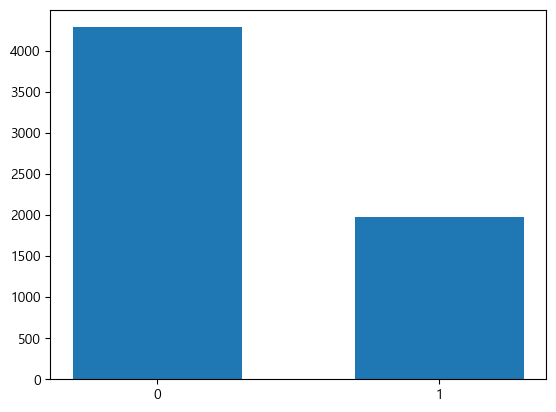

In [89]:
plt.hist(y,bins=[-0.5,0.5,1.5],rwidth=0.6)
plt.xticks([0,1])

1로 분류될 확률

In [90]:
y_scores=lo_model.predict_proba(X_test)[:,1]

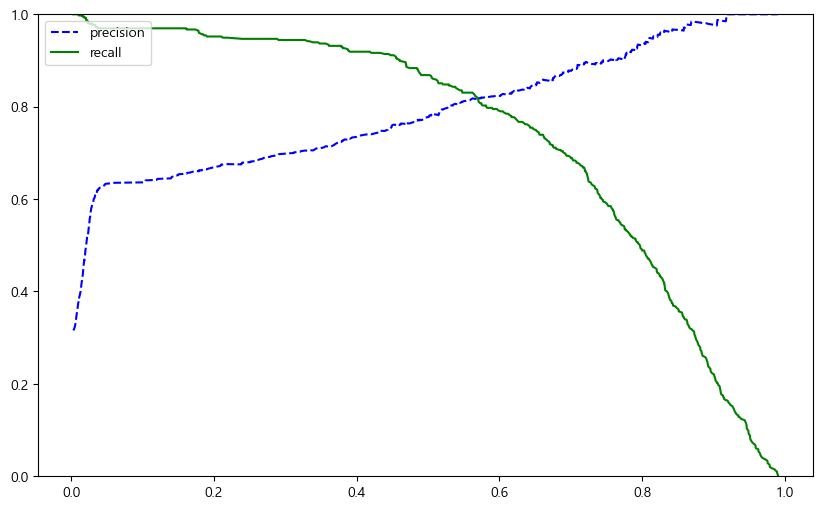

In [91]:
from sklearn.metrics import precision_recall_curve

# 다양한 임계값에 대한 정밀도와 재현율 계산
precisions,recalls,thresholds=precision_recall_curve(y_test,y_scores)

#임계값에 따른 정밀도와 재현율 시각화
plt.figure(figsize=(10,6))
plt.plot(thresholds,precisions[:-1],"b--",label='precision')
plt.plot(thresholds,recalls[:-1],"g-",label='recall')
plt.legend(loc='upper left')
plt.ylim([0,1])
plt.show()

In [92]:
thr=0.6
y_pred_cust=(y_scores >=thr).astype(int)

cm=confusion_matrix(y_test,y_pred_cust)
print('혼동행렬',cm)

accuracy=accuracy_score(y_test,y_pred_cust)
precision=precision_score(y_test,y_pred_cust)
recall=recall_score(y_test,y_pred_cust)
f1=f1_score(y_test,y_pred_cust)

print(f'Accuracy:{accuracy}')
print(f'precision:{precision}')
print(f'recall:{recall}')
print(f'f1_score:{f1}')

혼동행렬 [[789  67]
 [ 83 312]]
Accuracy:0.8800959232613909
precision:0.8232189973614775
recall:0.789873417721519
f1_score:0.8062015503875969


1. SMOTE 오버 샘플링 (데이터 보강)
2. 이재민 로그 스케일링
3. 0~1 분류
4. 1을 대상으로 재분류 또는 예측

In [101]:
from imblearn.over_sampling import SMOTE

df1['이재민_log']=np.log1p(df1['이재민 인'])
y = (df1['이재민_log'].astype(float) > 0).astype(int)


sm=SMOTE(random_state=42)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)
X_sm,y_sm=sm.fit_resample(X_train,y_train)


lo_model2=model.fit(X_train,y_train)

y_pred=lo_model2.predict(X_test)

cm=confusion_matrix(y_test,y_pred)
print('혼동행렬',cm)

accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

print(f'Accuracy:{accuracy}')
print(f'precision:{precision}')
print(f'recall:{recall}')
print(f'f1_score:{f1}')


혼동행렬 [[753  77]
 [ 87 334]]
Accuracy:0.8689048760991207
precision:0.8126520681265207
recall:0.7933491686460807
f1_score:0.8028846153846154


오버샘플링 후 결과
1. 정확도 : 0.86
2. 정밀도 : 0.81 -> 모델 예측력 / 예측한 값들 중 실제 위험 비율
3. 재현율 : 0.79 -> 실제 위험 지역 중 맞게 찾아낸 비율
4. f1 조화평균 : 0.80



([<matplotlib.axis.XTick at 0x269e72c60d0>,
 [Text(0, 0, '0'), Text(1, 0, '1')])

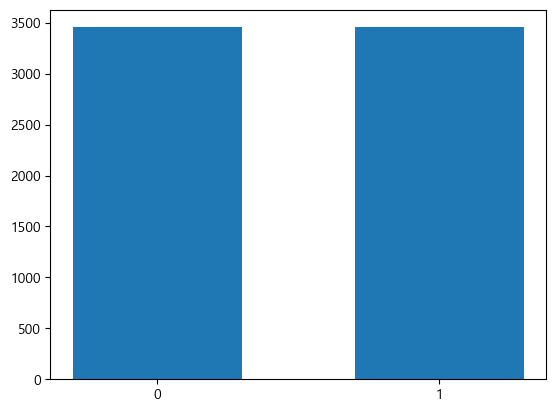

In [102]:
plt.hist(y_sm,bins=[-0.5,0.5,1.5],rwidth=0.6)
plt.xticks([0,1])

1. 전체 데이터에서 1로 분류된 행 추출
2. (1 )후보들을 사용해 다시 회귀 모델로 이재민 수 예측

In [116]:
df_pred1.columns

Index(['지역명', '연도', '인구밀도', '인구밀도_평균', '인구밀도_표준편차', '인구밀도_', '경사도_평균',
       '경사도_최대', '이재민 인', '건물피해액', '월', '월강수량', '이재민_scaled', '인구밀도_log',
       '월강수량_log', '강수대비_건물피해액', '고위험확률', '이재민_log', '발생확률', '발생예측'],
      dtype='object')

In [ ]:
pred_all=lo_model2.predict(X)
df_all=df1.copy()
df_all['발생예측']=pred1_all

df_pred1=df_all[df_all['발생예측']==1]
print("전체 중 1로 예측된 개수:", len(df_pred1))

전체 중 1로 예측된 개수: 2595


In [119]:

# ===== 2단계 회귀 학습: 실제로 이재민>0 인 데이터만으로 학습 =====
# 1단계 로지스틱 회귀 후 분류된 결과를 활용해 예측 모델링 실행
features = ['인구밀도_log','경사도_평균','월강수량_log','강수대비_건물피해액']

reg2 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("reg", ExtraTreesRegressor(n_estimators=600, random_state=42, n_jobs=-1))
])

df_pos_true = df_all[df_all['이재민 인'].astype(float) > 0].copy()
X2 = df_pos_true[features]
y2 = df_pos_true['이재민_log']
reg2.fit(X2, y2)


# 1차 로지스틱 회귀에서 1로 분류된 데이터 선별
X_pred = df_pred1[features].copy()
# 학습된 예측 모델을 통해 X_pred 실제 이재민 수 예측
pred_log = reg2.predict(X_pred)

df_pred1 = df_pred1.copy()
df_pred1["예측_이재민_log"] = pred_log
df_pred1["예측_이재민_명"] = np.expm1(pred_log)


# ===== 결과 확인: 예측 규모 큰 순으로 보기 =====
df_pred1_sorted = df_pred1.sort_values("예측_이재민_명", ascending=False)
print("1로 예측된 중 예측 규모 Top 20")
display(df_pred1_sorted[["지역명","연도","발생예측","예측_이재민_명","예측_이재민_log"]].head(20))


1로 예측된 중 예측 규모 Top 20


,지역명,연도,발생예측,예측_이재민_명,예측_이재민_log
2393,경상북도 영덕군,2018,1,2111.0,7.655391
2394,경상북도 영덕군,2018,1,2111.0,7.655391
2396,경상북도 영덕군,2018,1,2111.0,7.655391
2395,경상북도 영덕군,2018,1,2111.0,7.655391
3097,부산광역시 동래구,2014,1,1972.0,7.587311
3098,부산광역시 동래구,2014,1,1972.0,7.587311
3099,부산광역시 동래구,2014,1,1972.0,7.587311
3100,부산광역시 동래구,2014,1,1972.0,7.587311
2616,경상북도 울진군,2019,1,1729.0,7.455877
2615,경상북도 울진군,2019,1,1729.0,7.455877
